<a href="https://colab.research.google.com/github/pop123-ux/HuggingFace-Project-Learning/blob/main/nb/Gemma3_(1B)-GRPO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

To run this, press "*Runtime*" and press "*Run all*" on a **free** Tesla T4 Google Colab instance!
<div class="align-center"><a href="https://huggingface.co/learn/nlp-course/en/chapter12/6?fw=pt"><img src="https://github.com/unslothai/notebooks/raw/main/assets/hf%20course.png" width="165"></a>
<a href="https://unsloth.ai/"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
<a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord button.png" width="145"></a>
<a href="https://unsloth.ai/docs/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a> Join Discord if you need help + ⭐ <i>Star us on <a href="https://github.com/unslothai/unsloth">Github</a> </i> ⭐
</div>

In this [Hugging Face](https://huggingface.co/learn/nlp-course/en/chapter12/6?fw=pt) and Unsloth notebook, you will learn to transform Gemma3 (1B) GRPO into a Reasoning model using GRPO.

To install Unsloth on your local device, follow [our guide](https://unsloth.ai/docs/get-started/install). This notebook is licensed [LGPL-3.0](https://github.com/unslothai/notebooks?tab=LGPL-3.0-1-ov-file#readme).

You will learn how to do [data prep](#Data), how to [train](#Train), how to [run the model](#Inference), & how to save it

In [1]:
!pip install unsloth vllm
!pip install --upgrade pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of vllm to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 9.7 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of quack-kernels to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of cuda-tile[tileiras] to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.1/274.1 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 93.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.7/211.7 kB 20.8 MB/s eta 0:00:

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 69.3 MB/s eta 0:00:00
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
^C


We now set up Unsloth

In [1]:
from unsloth import FastLanguageModel


  uv pip install https://github.com/vllm-project/vllm/releases/download/v0.23.0/vllm-0.23.0+cu128-cp38-abi3-manylinux_2_35_x86_64.whl


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


Now, let’s load Google’s Gemma 3 1B Instruct model and configure it for fine-tuning:

In [3]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 1024  # Can increase for longer reasoning traces
lora_rank = 32  # Larger rank = smarter, but slower

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="google/gemma-3-1b-it",
    max_seq_length=max_seq_length,
    load_in_4bit=True,  # False for LoRA 16bit
    fast_inference=False,
    max_lora_rank=lora_rank,
    gpu_memory_utilization=0.6,  # Reduce if out of memory
)

model = FastLanguageModel.get_peft_model(
    model,
    r=lora_rank,  # Choose any number > 0 ! Suggested 8, 16, 32, 64, 128
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],  # Remove QKVO if out of memory
    lora_alpha=lora_rank,
    use_gradient_checkpointing="unsloth",  # Enable long context finetuning
    random_state=3407,
)


==((====))==  Unsloth 2026.7.5: Fast Gemma3 patching. Transformers: 4.57.6. vLLM: 0.23.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gemma3 won't work! Using float32.
Unsloth: Explicit target_modules are constrained by the finetune_(vision|language|attention|mlp) filters; adapters attach only where both select.


Now we prepare the data: for this exercise, we'll use the GSM8K dataset, which contains grade school math problems. We'll format the data to encourage the model to show its reasoning before providing an answer, but first we need to define the format of the prompts and answers:

In [ ]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 1024  # Can increase for longer reasoning traces
lora_rank = 32  # Larger rank = smarter, but slower

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="google/gemma-3-1b-it",
    max_seq_length=max_seq_length,
    load_in_4bit=True,  # False for LoRA 16bit
    fast_inference=True,  # Enable vLLM fast inference
    max_lora_rank=lora_rank,
    gpu_memory_utilization=0.6,  # Reduce if out of memory
)

model = FastLanguageModel.get_peft_model(
    model,
    r=lora_rank,  # Choose any number > 0 ! Suggested 8, 16, 32, 64, 128
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],  # Remove QKVO if out of memory
    lora_alpha=lora_rank,
    use_gradient_checkpointing="unsloth",  # Enable long context finetuning
    random_state=3407,
)

Now, we prepare the dataset:

In [ ]:
import re
from datasets import load_dataset, Dataset


# Helper functions to extract answers from different formats
def extract_xml_answer(text: str) -> str:
    answer = text.split("<answer>")[-1]
    answer = answer.split("</answer>")[0]
    return answer.strip()


def extract_hash_answer(text: str) -> str | None:
    if "####" not in text:
        return None
    return text.split("####")[1].strip()


# Function to prepare the GSM8K dataset
def get_gsm8k_questions(split="train") -> Dataset:
    data = load_dataset("openai/gsm8k", "main")[split]
    data = data.map(
        lambda x: {
            "prompt": [
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": x["question"]},
            ],
            "answer": extract_hash_answer(x["answer"]),
        }
    )
    return data


dataset = get_gsm8k_questions()

Now, the dataset is prepared by extracting the answer from the dataset and formatting it as a string.

## Defining Reward Functions ##

As discussed in the earlier notebooks, GRPO can use reward functions to guide the model's learning based on verifiable criteria like length and formatting.

In this exercise, we'll define several reward functions that encourage different aspects of good reasoning. For example, we'll reward the model for providing an integer answer, and for following the strict format.

In [ ]:
# Reward function that checks if the answer is correct
def correctness_reward_func(prompts, completions, answer, **kwargs) -> list[float]:
  responses = [completion[0]['content'] for completion in completions]
  q = prompts[0][-1]['content']
  extracted_responses = [extract_xml_answer(r) for r in responses]
  print(
        "-" * 20,
        f"Question:\n{q}",
        f"\nAnswer:\n{answer[0]}",
        f"\nResponse:\n{responses[0]}",
        f"\nExtracted:\n{extracted_responses[0]}",
  )
  return [2.0 if r == a else 0.0 for r, a in zip(extracted_responses, answer)]


# Reward function that checks if the answer is an integer
def int_reward_func(completions, **kwargs) -> list[float]:
  responses = [completion[0]['content'] for completion in completions]
  extracted_responses = [extract_xml_answer(r) for r in responses]
  return [0.5 if r.isdigit() else 0.0 for r in extracted_responses]

# Reward function that checks if the completion follows the strict format
def strict_format_reward_func(completions, **kwargs) -> list[float]:
  pattern = r"^<reasoning>\n.*?\n</reasoning>\n<answer>\n.*?\n</answer>\n$"
  responses = [completion[0]['content'] for completion in completions]
  matches = [re.match(pattern, r) for r in responses]
  return [0.5 if match else 0.0 for match in matches]

# Reward function that counts XML tags and penalizes extra content
def count_xml(text) -> float:
  count = 0.0
  if text.count("<reasoning>\n") == 1:
        count += 0.125
  if text.count("\n</reasoning>\n") == 1:
        count += 0.125
  if text.count("\n<answer>\n") == 1:
        count += 0.125
        count -= len(text.split("\n</answer>\n")[-1]) * 0.001
  if text.count("\n</answer>") == 1:
        count += 0.125
        count -= (len(text.split("\n</answer>")[-1]) - 1) * 0.001
  return count

def xmlcount_reward_func(completions, **kwargs) -> list[float]:
  contents = [completion[0]['content'] for completion in completions]
  return [count_xml(c) for c in contents]

These reward functions serve different purposes:
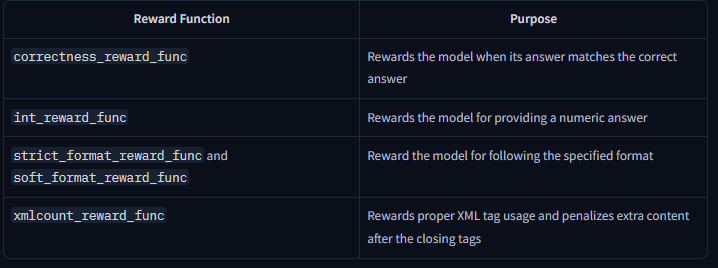

## Training with GRPO ##

Now we'll set up the GRPO trainer with our model, tokenizer, and reward functions. This part follows the same approach as my other GRPO notebooks

In [ ]:
from trl import GRPOConfig, GRPOTrainer

training_args = GRPOConfig(
    learning_rate=5e-6,
    adam_beta1=0.9,
    adam_beta2=0.99,
    weight_decay=0.1,
    warmup_ratio=0.1,
    lr_scheduler_type='cosine',
    optim='paged_adamw_8bit',
    logging_steps=1,
    per_device_train_batch_size=1,
    gradient_accumulation_steps1, # Consider increasing to 4 for smoother training
    num_generations=6, # Decrease if out of memory
    max_completion_length=max_seq_length - 256, # 256 shouled be the max_prompt_length
    max_steps=250,
    save_steps=250,
    max_grad_norm=0.1,
    report_to='none', # We can use W&B here
    output_dir='outputs',
)

trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=[
        xmlcount_reward_func,
        soft_format_reward_func,
        strict_format_reward_func,
        int_reward_func,
        correctness_reward_func,
    ],
    args=training_args,
    train_dataset=dataset,
)

The GRPOConfig sets various hyperparameters for training:
- use_vllm: Enables fast inference with vLLM
- learning_rate: Controls how quickly the model learns
- num_generations: Number of completions to generate for each prompt
- max_steps: Total number of training steps to perform

In [ ]:
trainer.train()

## Testing the Model ##

After training, let's test our model to see how it performs. First, we'll save the LoRA weights:

In [ ]:
model.save_lora('grpo_saved_lora')

Now, let's test the model with a new question:

In [ ]:
from vllm import SamplingParams

text = tokenizer.apply_chat_template(
    [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': "Calculate pi/2."},
    ],
    tokenize=False,
    add_generation_prompt=True,
)

sampling_params = SamplingParams(
    temperature=0.8,
    top_p=0.95,
    max_tokens=1024,
)
output = (
    model.fast_generate(
        text,
        sampling_params=sampling_params,
        lora_request=model.load_lora('grpo_saved_lora'),
    )[0]
    .outputs[0]
    .text
)

output

## Saving the Model ##

In [ ]:
# Save to 16-bit precision
model.save_pretrained_merged('model', tokenizer, save_method='merged-16bit')

## Pushing to Hugging Face Hub ##
This method allows us to push the model in multiple quantization formats.

In [ ]:
# Push to Hugging Face Hub (will require a token)
model.push_to_hub_merged(
    'your-username/model-name', tokenizer, save_method='merged_16bit', token='your-token'
)

# Conclusion #

In this exercise we learned how to:
1. Set up Unsloth for accelerated fine-tuning
2. Prepare data for GRPO training
3. Define custom reward functions to guide the model's learning
4. Train a model using GRPO
5. Test the fine-tuned model
6. Save the model in various formats

GRPO is a powerful technique for aligning language models with specific behaviors, and Unsloth makes it accessible even on limited computing power. By combining multiple reward functions, we can guide the model to follow a specific format while also improving its reasoning capabilities.